In [1]:
# ============================================================
# Dữ liệu thời tiết (Kaggle) — nhiệt độ, độ ẩm, điểm sương.
# ============================================================

import pandas as pd

df = pd.read_csv("data/data_Kaggle/cleaned_weather.csv")
df = df[["date", "T", "Tdew", "rh"]]

print("Data shape:", df.shape)
df.head()

Data shape: (52696, 4)


,date,T,Tdew,rh
0,2020-01-01 00:10:00,0.71,-1.33,86.1
1,2020-01-01 00:20:00,0.75,-1.44,85.2
2,2020-01-01 00:30:00,0.73,-1.48,85.1
3,2020-01-01 00:40:00,0.37,-1.64,86.3
4,2020-01-01 00:50:00,0.33,-1.50,87.4


In [2]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
)

print("Số dòng thiếu dữ liệu:", df.isna().any(axis=1).sum())

Số dòng thiếu dữ liệu: 0


In [3]:
import time

# ============================================================
# Genetic Programming cho Symbolic Regression — xem
# 04_symbolic_regression.ipynb để biết chi tiết thiết kế engine.
# ============================================================

FUNCTIONS_ARITY = {
    "+": 2, "*": 2, "/": 2, "log": 1,
}


def protected_div(a, b):
    with np.errstate(divide="ignore", invalid="ignore"):
        ket_qua = np.divide(a, b)
    return np.where(np.isfinite(ket_qua), ket_qua, 1.0)


def protected_log(a):
    with np.errstate(divide="ignore", invalid="ignore"):
        ket_qua = np.log(np.abs(a))
    return np.where(np.isfinite(ket_qua), ket_qua, 0.0)


def apply_op(op, args):
    if op == "+":
        return args[0] + args[1]
    if op == "*":
        return args[0] * args[1]
    if op == "/":
        return protected_div(args[0], args[1])
    if op == "log":
        return protected_log(args[0])
    raise ValueError(f"Toán tử không xác định: {op}")


class Node:
    __slots__ = ("op", "children")

    def __init__(self, op, children=None):
        self.op = op
        self.children = children if children is not None else []


def is_variable(op):
    return isinstance(op, str) and op.startswith("x") and op[1:].isdigit()


def eval_node(node, X):
    if is_variable(node.op):
        return X[:, int(node.op[1:])]
    if isinstance(node.op, (int, float)):
        return node.op
    args = [eval_node(con, X) for con in node.children]
    return apply_op(node.op, args)


def tree_depth(node):
    if not node.children:
        return 1
    return 1 + max(tree_depth(con) for con in node.children)


def tree_size(node):
    return 1 + sum(tree_size(con) for con in node.children)


def copy_tree(node):
    return Node(node.op, [copy_tree(con) for con in node.children])


def all_nodes(node):
    nodes = [node]
    for con in node.children:
        nodes.extend(all_nodes(con))
    return nodes


def tree_to_string(node, feature_names):
    if is_variable(node.op):
        return feature_names[int(node.op[1:])]
    if isinstance(node.op, (int, float)):
        return str(node.op)
    if len(node.children) == 1:
        return f"{node.op}({tree_to_string(node.children[0], feature_names)})"
    return (f"({tree_to_string(node.children[0], feature_names)} {node.op} "
            f"{tree_to_string(node.children[1], feature_names)})")


def random_terminal(rng, n_features):
    if rng.random() < 0.5:
        idx = rng.integers(0, n_features)
        return Node(f"x{idx}")
    return Node(round(float(rng.uniform(-2, 2)), 3))


def random_tree(rng, depth_remaining, method, n_features):
    la_la = depth_remaining <= 1 or (method == "grow" and rng.random() < 0.3)
    if la_la:
        return random_terminal(rng, n_features)
    op = rng.choice(list(FUNCTIONS_ARITY.keys()))
    arity = FUNCTIONS_ARITY[op]
    return Node(op, [random_tree(rng, depth_remaining - 1, method, n_features) for _ in range(arity)])


def init_population(rng, population_size, min_depth, max_depth, n_features):
    population = []
    do_sau_list = list(range(min_depth, max_depth + 1))
    for i in range(population_size):
        do_sau = do_sau_list[i % len(do_sau_list)]
        method = "full" if i % 2 == 0 else "grow"
        population.append(random_tree(rng, do_sau, method, n_features))
    return population


def crossover(rng, parent1, parent2, max_depth):
    child1 = copy_tree(parent1)
    child2 = copy_tree(parent2)

    nodes1 = all_nodes(child1)
    nodes2 = all_nodes(child2)
    diem1 = nodes1[rng.integers(0, len(nodes1))]
    diem2 = nodes2[rng.integers(0, len(nodes2))]

    diem1.op, diem2.op = diem2.op, diem1.op
    diem1.children, diem2.children = diem2.children, diem1.children

    if tree_depth(child1) > max_depth or tree_depth(child2) > max_depth:
        return copy_tree(parent1), copy_tree(parent2)

    return child1, child2


def mutate_subtree(rng, individual, max_depth, n_features):
    # Đột biến thay thế cây con: chọn ngẫu nhiên một nút, thay cây con
    # bắt rễ tại đó bằng một cây con mới sinh ngẫu nhiên.
    child = copy_tree(individual)
    nodes = all_nodes(child)
    diem = nodes[rng.integers(0, len(nodes))]

    cay_moi = random_tree(rng, int(rng.integers(1, 4)), rng.choice(["grow", "full"]), n_features)
    diem.op = cay_moi.op
    diem.children = cay_moi.children

    if tree_depth(child) > max_depth:
        return copy_tree(individual)

    return child


def mutate_point(rng, individual, n_features):
    # Đột biến điểm: giữ nguyên cấu trúc cây, chỉ đổi một nút hàm sang
    # hàm khác cùng số ngôi, hoặc một nút lá sang biến/hằng số khác.
    child = copy_tree(individual)
    nodes = all_nodes(child)
    diem = nodes[rng.integers(0, len(nodes))]

    if diem.children:
        arity = len(diem.children)
        cung_ngoi = [op for op, ar in FUNCTIONS_ARITY.items() if ar == arity and op != diem.op]
        if cung_ngoi:
            diem.op = cung_ngoi[rng.integers(0, len(cung_ngoi))]
    else:
        diem.op = random_terminal(rng, n_features).op

    return child


def mutate_hoist(rng, individual):
    # Đột biến rút gọn: thay toàn bộ cây bằng một cây con ngẫu nhiên
    # bên trong nó, giúp thu nhỏ cây một cách có kiểm soát (chống bloat).
    nodes = all_nodes(individual)
    if len(nodes) <= 1:
        return copy_tree(individual)
    ung_vien = nodes[1:]
    chon = ung_vien[rng.integers(0, len(ung_vien))]
    return copy_tree(chon)


def mutate(rng, individual, max_depth, n_features):
    loai = rng.choice(["subtree", "point", "hoist"])
    if loai == "subtree":
        return mutate_subtree(rng, individual, max_depth, n_features)
    if loai == "point":
        return mutate_point(rng, individual, n_features)
    return mutate_hoist(rng, individual)


def tournament_selection(rng, population, fitnesses, tournament_size):
    indices = rng.integers(0, len(population), size=tournament_size)
    best_index = indices[np.argmin(fitnesses[indices])]
    return population[best_index]


PARSIMONY_COEF = 0.0001


def compute_mse(node, X, y):
    y_pred = eval_node(node, X)
    y_pred = np.broadcast_to(np.asarray(y_pred, dtype=float), (X.shape[0],))

    if not np.all(np.isfinite(y_pred)):
        return np.inf

    return np.mean((y_pred - y) ** 2)


def compute_mae(node, X, y):
    y_pred = eval_node(node, X)
    y_pred = np.broadcast_to(np.asarray(y_pred, dtype=float), (X.shape[0],))

    if not np.all(np.isfinite(y_pred)):
        return np.inf

    return np.mean(np.abs(y_pred - y))


def fitness(node, X, y):
    return compute_mse(node, X, y) + PARSIMONY_COEF * tree_size(node)


CROSSOVER_RATE = 0.8
MUTATION_RATE = 0.2
ELITE_SIZE = 200
TOURNAMENT_SIZE = 3


def genetic_programming(
    X, y,
    population_size,
    generations,
    max_depth=6,

    crossover_rate=CROSSOVER_RATE,
    mutation_rate=MUTATION_RATE,
    elite_size=ELITE_SIZE,
    tournament_size=TOURNAMENT_SIZE,

    seed=42,
):
    rng = np.random.default_rng(seed)
    n_features = X.shape[1]

    population = init_population(rng, population_size, min_depth=2, max_depth=max_depth, n_features=n_features)
    fitnesses = np.array([fitness(ind, X, y) for ind in population])

    best_index = int(np.argmin(fitnesses))
    best_tree = copy_tree(population[best_index])
    best_fitness = fitnesses[best_index]

    history = []
    mse_history = []
    mae_history = []

    start_time = time.perf_counter()

    for generation in range(generations):

        current_best = int(np.argmin(fitnesses))
        if fitnesses[current_best] < best_fitness:
            best_fitness = fitnesses[current_best]
            best_tree = copy_tree(population[current_best])

        history.append(best_fitness)
        mse_history.append(compute_mse(best_tree, X, y))
        mae_history.append(compute_mae(best_tree, X, y))

        order = np.argsort(fitnesses)
        new_population = [copy_tree(population[i]) for i in order[:elite_size]]

        while len(new_population) < population_size:
            parent1 = tournament_selection(rng, population, fitnesses, tournament_size)
            parent2 = tournament_selection(rng, population, fitnesses, tournament_size)

            if rng.random() < crossover_rate:
                child1, child2 = crossover(rng, parent1, parent2, max_depth)
            else:
                child1, child2 = copy_tree(parent1), copy_tree(parent2)

            if rng.random() < mutation_rate:
                child1 = mutate(rng, child1, max_depth, n_features)
            if rng.random() < mutation_rate:
                child2 = mutate(rng, child2, max_depth, n_features)

            new_population.append(child1)
            if len(new_population) < population_size:
                new_population.append(child2)

        population = new_population
        fitnesses = np.array([fitness(ind, X, y) for ind in population])

    current_best = int(np.argmin(fitnesses))
    if fitnesses[current_best] < best_fitness:
        best_fitness = fitnesses[current_best]
        best_tree = copy_tree(population[current_best])

    elapsed_time = time.perf_counter() - start_time

    generations_run = int(np.argmin(history)) + 1

    return {
        "tree": best_tree,
        "fitness": best_fitness,
        "time": elapsed_time,
        "history": history,
        "mse_history": mse_history,
        "mae_history": mae_history,
        "generations": generations,
        "generations_run": generations_run,
        "seed": seed,
    }

In [4]:
# ============================================================
# SYMBOLIC REGRESSION — dự đoán điểm sương (Tdew) từ nhiệt độ (T)
# và độ ẩm tương đối (rh). Quan hệ thật là công thức Magnus, có
# dạng log/chia phi tuyến.
# ============================================================

FEATURE_COLS = ["T", "rh"]
TARGET_COL = "Tdew"

X_train, X_test, y_train, y_test = train_test_split(
    df[FEATURE_COLS], df[TARGET_COL],
    test_size=0.2, random_state=42,
)

X_train_arr = X_train.to_numpy()
X_test_arr = X_test.to_numpy()
y_train_arr = y_train.to_numpy()
y_test_arr = y_test.to_numpy()

print(f"Train: {len(X_train)} dòng")
print(f"Test : {len(X_test)} dòng")

Train: 42156 dòng
Test : 10540 dòng


In [5]:
PARSIMONY_COEF = 0.01

GP_POPULATION_SIZE = 10000
GP_GENERATIONS = 500
GP_MAX_DEPTH = 6

gp_result = genetic_programming(
    X_train_arr, y_train_arr,
    population_size=GP_POPULATION_SIZE,
    generations=GP_GENERATIONS,
    max_depth=GP_MAX_DEPTH,
    seed=42,
)

print(f"Thời gian chạy GP: {gp_result['time']:.2f}s")
print(f"Fitness tốt nhất (MSE + phạt kích thước): {gp_result['fitness']:.4f}")
print(f"Đạt được từ thế hệ: {gp_result['generations_run']}/{gp_result['generations']}")
print(f"Kích thước cây: {tree_size(gp_result['tree'])} nút, độ sâu {tree_depth(gp_result['tree'])}")
print(f"\nBiểu thức GP tìm được (dự đoán Tdew):\n{tree_to_string(gp_result['tree'], FEATURE_COLS)}")

Thời gian chạy GP: 5028.59s
Fitness tốt nhất (MSE + phạt kích thước): 0.3615
Đạt được từ thế hệ: 499/500
Kích thước cây: 24 nút, độ sâu 6

Biểu thức GP tìm được (dự đoán Tdew):
(log(log((0.325 / log(rh)))) * ((-1.46 / ((rh * -0.121) * (-0.121 * 0.161))) + (((-0.489 * -0.121) * rh) + T)))


In [6]:
y_pred = eval_node(gp_result["tree"], X_test_arr)
y_pred = np.broadcast_to(np.asarray(y_pred, dtype=float), (X_test_arr.shape[0],))

mae = mean_absolute_error(y_test_arr, y_pred)
rmse = mean_squared_error(y_test_arr, y_pred) ** 0.5
r2 = r2_score(y_test_arr, y_pred)

print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2  : {r2:.4f}")

MAE : 0.2659
RMSE: 0.3439
R2  : 0.9967


In [7]:
import matplotlib.pyplot as plt


def show_gp_convergence(result):
    SURFACE, INK, INK_MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e4e3df"

    rmse_history = np.sqrt(result["mse_history"])
    mae_history = result["mae_history"]
    generation = np.arange(1, len(rmse_history) + 1)
    converged_at = result["generations_run"]

    fig, ax = plt.subplots(figsize=(7.5, 4.6), facecolor=SURFACE)
    ax.set_facecolor(SURFACE)

    ax.plot(generation, rmse_history, color="#2a78d6", linewidth=2, label="RMSE")
    ax.plot(generation, mae_history, color="#eb6834", linewidth=2, label="MAE")
    ax.axvline(
        converged_at, color=INK_MUTED, linewidth=1.4, linestyle="--",
        label=f"Hội tụ ở thế hệ {converged_at}",
    )

    ax.set_xlim(0, result["generations"])
    ax.set_xticks(np.arange(0, result["generations"] + 1, 50))
    ax.set_xlabel("Thế hệ", color=INK_MUTED, fontsize=11)
    ax.set_ylabel("Sai số", color=INK_MUTED, fontsize=11)
    ax.set_title("GP — RMSE và MAE tốt nhất qua các thế hệ (dự đoán Tdew)",
                 color=INK, fontsize=12, pad=10)

    ax.grid(True, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(colors=INK_MUTED, labelsize=9)
    for spine in ax.spines.values():
        spine.set_color(GRID)

    legend = ax.legend(frameon=False, fontsize=10)
    for text in legend.get_texts():
        text.set_color(INK_MUTED)

    fig.tight_layout()
    plt.show()

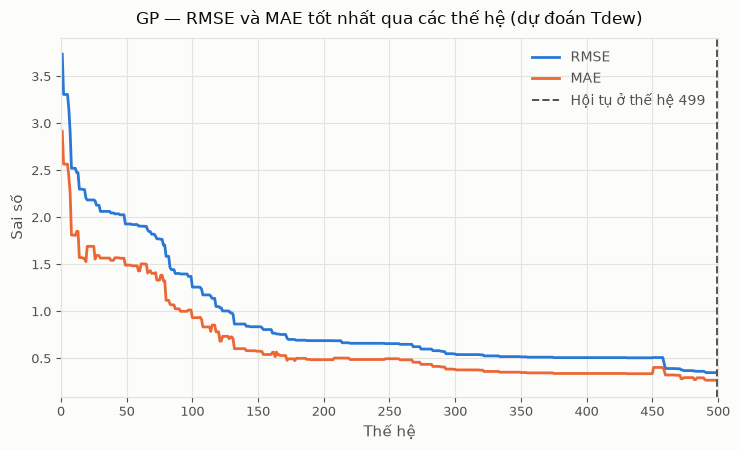

In [8]:
show_gp_convergence(gp_result)

In [9]:
def compute_positions(node, positions, next_x, depth=0):
    if not node.children:
        positions[id(node)] = (next_x[0], -depth)
        next_x[0] += 1
        return positions[id(node)][0]
    xs = [compute_positions(c, positions, next_x, depth + 1) for c in node.children]
    x = sum(xs) / len(xs)
    positions[id(node)] = (x, -depth)
    return x


def node_label(node, feature_names):
    if is_variable(node.op):
        return feature_names[int(node.op[1:])]
    if isinstance(node.op, (int, float)):
        return f"{node.op:.2g}"
    return node.op


def draw_tree(ax, root, feature_names, title):
    positions = {}
    compute_positions(root, positions, next_x=[0])

    def draw_edges(n):
        nx, ny = positions[id(n)]
        for c in n.children:
            cx, cy = positions[id(c)]
            ax.plot([nx, cx], [ny, cy], color="#aaaaaa", linewidth=1.2, zorder=1)
            draw_edges(c)

    draw_edges(root)

    for n in all_nodes(root):
        x, y = positions[id(n)]
        is_leaf = not n.children
        is_const = is_leaf and isinstance(n.op, (int, float))
        color = "#dbe9ff" if not is_leaf else ("#ffe8cc" if is_const else "#d9f2d9")
        ax.scatter([x], [y], s=550, color=color, edgecolor="#333333", zorder=2, linewidth=1)
        ax.text(x, y, node_label(n, feature_names), ha="center", va="center",
                fontsize=7.5, zorder=3)

    ax.set_title(title, fontsize=13, pad=10)
    ax.axis("off")
    xs = [positions[id(n)][0] for n in all_nodes(root)]
    ys = [positions[id(n)][1] for n in all_nodes(root)]
    ax.set_xlim(min(xs) - 1, max(xs) + 1)
    ax.set_ylim(min(ys) - 1, 1)

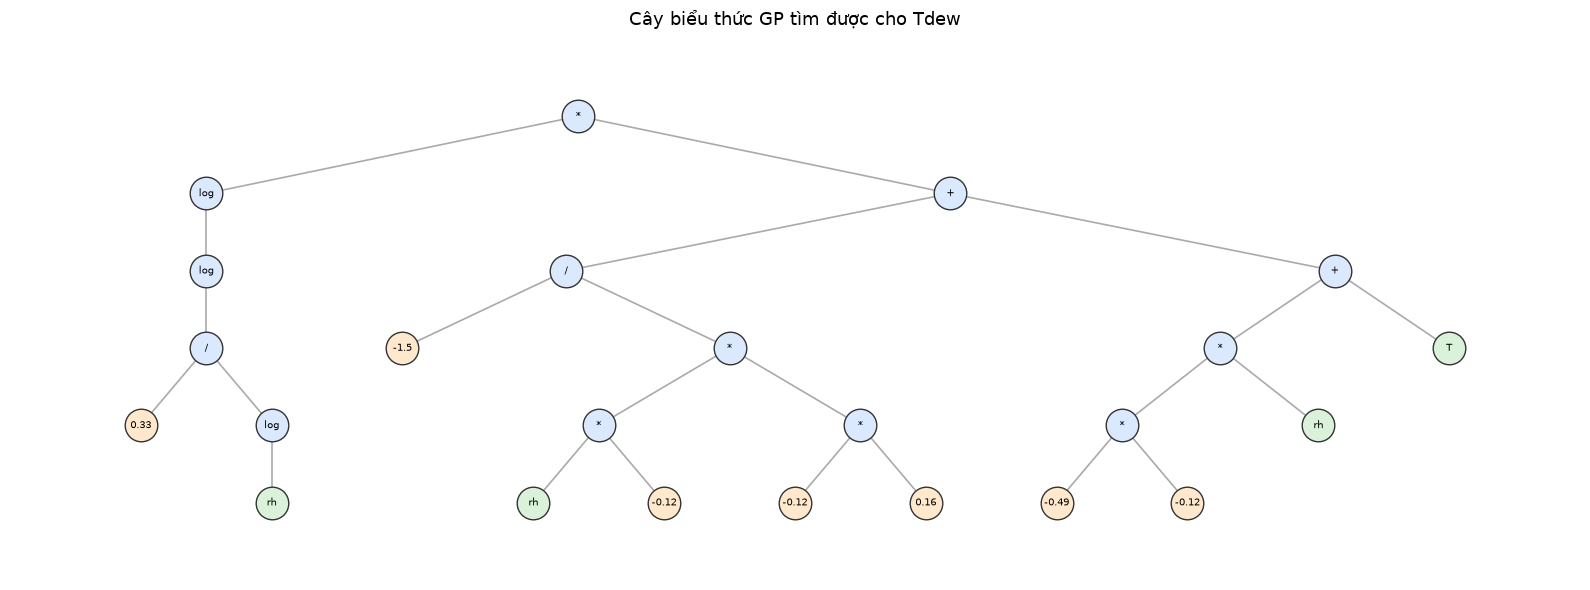

In [10]:
fig, ax = plt.subplots(figsize=(16, 6))
draw_tree(ax, gp_result["tree"], FEATURE_COLS, "Cây biểu thức GP tìm được cho Tdew")
fig.tight_layout()
plt.show()